## Akses model AI populer melalui Google-Colab-AI Tanpa Kunci API
Semua pengguna memiliki akses ke sebagian besar LLM populer melalui library Python <code>google-colab-ai</code>, dan pengguna berbayar memiliki akses ke pilihan model yang lebih banyak. Untuk mengetahui detail selengkapnya, lihat <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">memulai penggunaan google colab ai</a>.



In [65]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# @title Teks judul default
!pip install yfinance

In [ ]:
import pandas as pd



In [ ]:
import pandas as pd

# Contoh membaca file Excel
# Karena Anda memiliki file 'TPIA.xlsx' di '/content/TPIA.xlsx', kita bisa menggunakannya.
df_excel = pd.read_excel('/TPIA.xlsx')
print('DataFrame dari Excel:')
display(df_excel.head())

In [ ]:
import yfinance as yf

df = yf.download(
    "TPIA.JK",
    start="2015-01-01",
    end="2026-06-12"
)

df.head()

In [ ]:
df.to_excel("TPIA.xlsx")

In [ ]:
from google.colab import files

files.download("TPIA.xlsx")

In [ ]:
import pandas as pd

df = pd.read_excel("/TPIA.xlsx")

df.head()

In [ ]:
print(df.shape)

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
print(df['Date'].min())
print(df['Date'].max())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'])

plt.title('Harga Penutupan Saham TPIA')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')

plt.show()

In [ ]:
import numpy as np
df['log_close'] = np.log(df['Close'])
df['return'] = df['log_close'].diff()

In [ ]:
import numpy as np
df['log_volume'] = np.log(df['Volume'] + 1e-9) # Add a small constant to avoid log(0)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['return'].dropna(), bins=50, edgecolor='black') # dropna() to handle potential NaN values from .diff()
plt.title('Distribusi Return Saham TPIA')
plt.xlabel('Return Logaritmik')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_excel('/TPIA.xlsx')

df.head()

In [ ]:
print(df.columns)

In [ ]:
import numpy as np

df['log_close'] = np.log(df['Close'])

df['log_volume'] = np.log(
    df['Volume']
      .replace(0, np.nan)
      .ffill()
)

In [ ]:
# The error occurred because 'Date' was the DataFrame's index, not a regular column,
# when the code attempted to access df['Date'].

# First, ensure 'Date' is a column if it's currently the index.
if 'Date' == df.index.name:
    df.reset_index(inplace=True)

# Now 'Date' should be a column. Convert it to datetime.
df['Date'] = pd.to_datetime(df['Date'])

# Sort the DataFrame by the 'Date' column.
df = df.sort_values('Date')

# Set the 'Date' column as the DataFrame's index.
df.set_index('Date', inplace=True)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    2,
    1,
    figsize=(15,8),
    sharex=True
)

ax[0].plot(df.index, df['log_close'])
ax[0].set_title('Log Harga Penutupan TPIA')
ax[0].set_ylabel('Log Close')

ax[1].plot(df.index, df['log_volume'])
ax[1].set_title('Log Volume Perdagangan TPIA')
ax[1].set_ylabel('Log Volume')

plt.tight_layout()
plt.show()

In [ ]:
from pandas.plotting import lag_plot

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

lag_plot(df['return'], lag=1, ax=ax[0])
ax[0].set_title('Lag Plot Return (Lag 1)')

lag_plot(df['return'], lag=2, ax=ax[1])
ax[1].set_title('Lag Plot Return (Lag 2)')

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

plot_acf(
    df['return'],
    lags=30,
    ax=ax[0]
)

plot_pacf(
    df['return'],
    lags=30,
    ax=ax[1]
)

ax[0].set_title('ACF Return')
ax[1].set_title('PACF Return')

plt.tight_layout()
plt.show()

In [ ]:
df['abs_return'] = abs(df['return'])

In [ ]:
corr_volatility = df_excel['log_volume'].corr(df_excel['abs_return'])

corr_return = df_excel['log_volume'].corr(df_excel['return'])

print('Korelasi volume dan |return| :', corr_volatility)
print('Korelasi volume dan return :', corr_return)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_excel['log_volume'],
    df_excel['abs_return'],
    alpha=0.3
)

plt.xlabel('Log Volume')
plt.ylabel('|Return|')
plt.title('Hubungan Log Volume dan Volatilitas Harga')

plt.show()

In [ ]:
%whos



4.1 Persiapan Data Training dan Testing


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

# --- Ensure the Excel file exists and df is populated ---
# Download data using yfinance
df_temp = yf.download(
    "TPIA.JK",
    start="2017-01-01",
    end="2026-06-12"
)

# Save to TPIA.xlsx in the /content/ directory
df_temp.to_excel('/content/TPIA.xlsx')

# Re-load df from the newly created file, specifying header rows and index column
# This correctly reads the multi-level header and sets the Date as index
df = pd.read_excel('/content/TPIA.xlsx', header=[0, 1], index_col=0)

# Flatten the MultiIndex columns generated by yfinance output
# This converts columns like ('Open', 'TPIA.JK') to 'Open'
df.columns = [col[0] for col in df.columns]

# Ensure the index is a DatetimeIndex and sorted (it should be from index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Calculate log_close and log_volume
df['log_close'] = np.log(df['Close'])
df['log_volume'] = np.log(df['Volume'].replace(0, np.nan).ffill().bfill()) # Added .bfill() here to handle leading NaNs

# Explicitly reassign df after dropping rows where log_volume or log_close is NaN
# This ensures no missing exogenous data or target variable values are passed to the model
df = df.dropna(subset=['log_close', 'log_volume'])

# Variabel target
y = df['log_close']
x = df['log_volume'] # Define x here after df is cleaned

# 60 hari terakhir sebagai testing
train = y[:-60]
test = y[-60:]

x_train = x[:-60] # x_train and x_test should align with y_train and y_test
x_test = x[-60:]

print("Jumlah data train :", len(train))
print("Jumlah data test  :", len(test))

4.2 Baseline Model — Naive Forecast

In [ ]:
import numpy as np

naive_pred = []

history = train.copy()

for actual in test:

    forecast = history.iloc[-1]

    naive_pred.append(forecast)

    history = pd.concat([
        history,
        pd.Series([actual])
    ])

In [ ]:
actual_price = np.exp(test)

naive_price = np.exp(
    pd.Series(
        naive_pred,
        index=test.index
    )
)

hitungan RMSE

In [ ]:
from sklearn.metrics import mean_squared_error

rmse_naive = np.sqrt(
    mean_squared_error(
        actual_price,
        naive_price
    )
)

print(rmse_naive)

4.3 Mean / Drift Forecast

In [ ]:
df['return'] = df['log_close'].diff()
mean_return = df['return'].mean()

print(mean_return)

Forecasting

In [ ]:
drift_pred = []

history = train.copy()

for actual in test:

    forecast = history.iloc[-1] + mean_return

    drift_pred.append(forecast)

    history = pd.concat([
        history,
        pd.Series([actual])
    ])

Methode RMSE

In [ ]:
drift_price = np.exp(
    pd.Series(
        drift_pred,
        index=test.index
    )
)

rmse_drift = np.sqrt(
    mean_squared_error(
        actual_price,
        drift_price
    )
)

print(rmse_drift)

ARIMA

FIT model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(
    train,
    order=(0,1,2)
)

fit_arima = model_arima.fit()

print(
    fit_arima.summary()
)

print(
    fit_arima.params
)

AIC dan BIC model

In [ ]:
print("AIC :", fit_arima.aic)

print("BIC :", fit_arima.bic)

Rolling Forecast ARIMA

In [ ]:
arima_pred = []

history = train.copy()

for actual in test:

    model = ARIMA(
        history,
        order=(0,1,2)
    )

    fit = model.fit()

    forecast = fit.forecast(
        steps=1
    )

    arima_pred.append(
        forecast.iloc[0]
    )

    history = pd.concat([
        history,
        pd.Series([actual])
    ])

RMSE ARIMA

In [ ]:
arima_price = np.exp(
    pd.Series(
        arima_pred,
        index=test.index
    )
)

rmse_arima = np.sqrt(
    mean_squared_error(
        actual_price,
        arima_price
    )
)

print(rmse_arima)

4.5 ARIMAX(0,1,2) + Volume

Variabel Exogenous

In [ ]:
import numpy as np

# df['log_volume'] is now computed in Gqh6keWXkyb0, ensuring it's always present
# and aligned with the current df's date range (starting 2017).
x = df['log_volume']

# Split x into train and test sets, consistent with y (log_close)
x_train = x[:-60]
x_test = x[-60:]

Fit ARIMAX

In [ ]:
model_arimax = ARIMA(
    train,
    exog=x_train,
    order=(0,1,2)
)

fit_arimax = model_arimax.fit()

print(
    fit_arimax.summary()
)


In [ ]:
print(
    fit_arimax.params
)

AIC dan BIC

In [ ]:
print("AIC :", fit_arimax.aic)

print("BIC :", fit_arimax.bic)

Rolling Forecast ARIMAX

In [ ]:
arimax_pred = []

history_y = train.copy()

# Ensure history_x aligns with history_y (train)
# train's index corresponds to the training period of the log_close series from df
# So, take the log_volume from df for the same index period.
history_x = df['log_volume'].loc[train.index].copy()

for i in range(len(test)):

    model = ARIMA(
        history_y,
        exog=history_x,
        order=(0,1,2)
    )

    fit = model.fit()

    forecast = fit.forecast(
        steps=1,
        exog=x_test.iloc[[i]]
    )

    arimax_pred.append(
        forecast.iloc[0]
    )

    # Update history_y and history_x with the actual observation from the test set
    history_y = pd.concat([
        history_y,
        pd.Series([test.iloc[i]], index=[test.index[i]])
    ])

    history_x = pd.concat([
        history_x,
        pd.Series([x_test.iloc[i]], index=[x_test.index[i]])
    ])

RMSE ARIMAX

In [ ]:
arimax_price = np.exp(
    pd.Series(
        arimax_pred,
        index=test.index
    )
)

rmse_arimax = np.sqrt(
    mean_squared_error(
        actual_price,
        arimax_price
    )
)

print(rmse_arimax)

4.6 Ringkasan Hasil

In [ ]:
import pandas as pd
import numpy as np

hasil_model = pd.DataFrame({
    "Model": [
        "Naive",
        "Mean/Drift",
        "ARIMA(0,1,2)",
        "ARIMAX(0,1,2) + Volume"
    ],

    "RMSE (IDR)": [
        round(rmse_naive, 1),
        round(rmse_drift, 1),
        round(rmse_arima, 1),
        round(rmse_arimax, 1)
    ],

    "AIC": [
        np.nan,
        np.nan,
        round(fit_arima.aic, 1),
        round(fit_arimax.aic, 1)
    ],

    "BIC": [
        np.nan,
        np.nan,
        round(fit_arima.bic, 1),
        round(fit_arimax.bic, 1)
    ]
})

hasil_model

Visualisasi Perbandingan RMSE

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    summary["Model"],
    summary["RMSE"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center'
    )

plt.title(
    'Perbandingan RMSE Model'
)

plt.ylabel(
    'RMSE'
)

plt.show()

Gambar Forecast vs Aktual

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_price.index,
    actual_price,
    label='Actual',
    linewidth=2
)

plt.plot(
    arimax_price.index,
    arimax_price,
    label='ARIMAX Forecast'
)

plt.legend()

plt.title(
    'Actual vs Forecast\n60 Hari Testing'
)

plt.show()

4.7 Forecast 30 Hari ke Depan

In [68]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

results = []

for p in range(4):
    for d in range(3):
        for q in range(4):

            try:
                model = ARIMA(
                    df['log_close'],
                    order=(p,d,q)
                )

                fit = model.fit()

                results.append([
                    (p,d,q),
                    fit.aic,
                    fit.bic
                ])

            except:
                pass

results = pd.DataFrame(
    results,
    columns=['Order','AIC','BIC']
)

results.sort_values('AIC').head(10)

best_order = (1,1,1)

best_model = ARIMA(
    df['log_close'],
    order=best_order
).fit()

print(best_model.summary())

forecast_result = best_model.get_forecast(
    steps=30
)

forecast_log = forecast_result.predicted_mean

forecast_price = np.exp(
    forecast_log
)

forecast_price.head()

                               SARIMAX Results                                
Dep. Variable:              log_close   No. Observations:                 2324
Model:                 ARIMA(1, 1, 1)   Log Likelihood                4737.578
Date:                Mon, 15 Jun 2026   AIC                          -9469.156
Time:                        18:56:56   BIC                          -9451.904
Sample:                             0   HQIC                         -9462.869
                               - 2324                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4559      0.066      6.915      0.000       0.327       0.585
ma.L1         -0.3440      0.070     -4.900      0.000      -0.482      -0.206
sigma2         0.0010   1.14e-05     86.698      0.0

,predicted_mean
2324,1782.922179
2325,1781.975612
2326,1781.544197
2327,1781.347530
2328,1781.257868


In [67]:
future_dates = pd.bdate_range(
    start=df.index[-1],
    periods=31
)[1:]

# Get 95% confidence interval (default alpha=0.05)
conf_int_95 = forecast_result.conf_int(alpha=0.05)
lower_95 = conf_int_95.iloc[:, 0]
upper_95 = conf_int_95.iloc[:, 1]

# Get 80% confidence interval (alpha=0.20)
conf_int_80 = forecast_result.conf_int(alpha=0.20)
lower_80 = conf_int_80.iloc[:, 0]
upper_80 = conf_int_80.iloc[:, 1]

forecast_df = pd.DataFrame({
    'Forecast': forecast_price.values,
    'Lower_95': lower_95.values,
    'Upper_95': upper_95.values,
    'Lower_80': lower_80.values,
    'Upper_80': upper_80.values
}, index=future_dates)

forecast_df.head()

,Forecast,Lower_95,Upper_95,Lower_80,Upper_80
2026-06-12,1782.922179,7.424310,7.547708,7.445666,7.526351
2026-06-15,1781.975612,7.393210,7.577746,7.425147,7.545809
2026-06-16,1781.544197,7.368351,7.602121,7.408809,7.561663
2026-06-17,1781.347530,7.347216,7.623035,7.394951,7.575300
2026-06-18,1781.257868,7.328639,7.641511,7.382787,7.587363


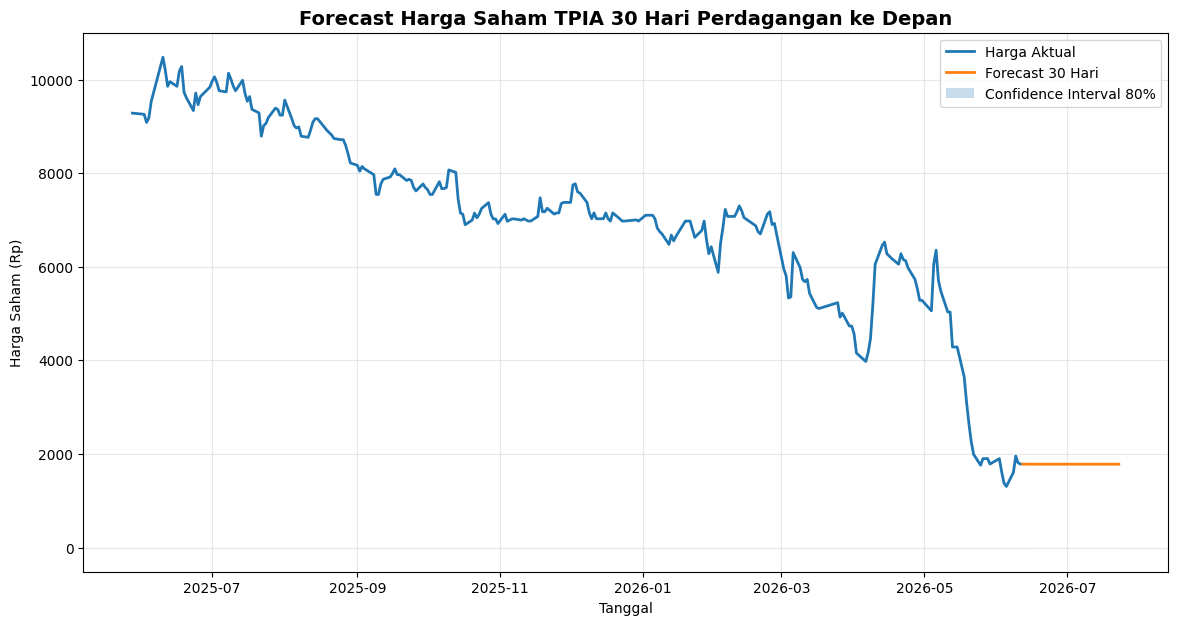

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# Harga historis 250 hari terakhir
plt.plot(
    np.exp(df['log_close'].tail(250)),
    linewidth=2,
    label='Harga Aktual'
)

# Forecast
plt.plot(
    forecast_df.index,
    forecast_df['Forecast'],
    linewidth=2,
    label='Forecast 30 Hari'
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df['Lower_80'],
    forecast_df['Upper_80'],
    alpha=0.25,
    label='Confidence Interval 80%'
)

plt.title(
    'Forecast Harga Saham TPIA 30 Hari Perdagangan ke Depan',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Tanggal')
plt.ylabel('Harga Saham (Rp)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()